In [0]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import seaborn as sns

In [0]:
input_path = '/dbfs/mnt/thesis/output_data/'

df = pd.read_csv(input_path + "processed_data.csv", parse_dates=["DATETIME"])
df = df[df['DATETIME'] < '2010-08-01'].copy(deep=True)

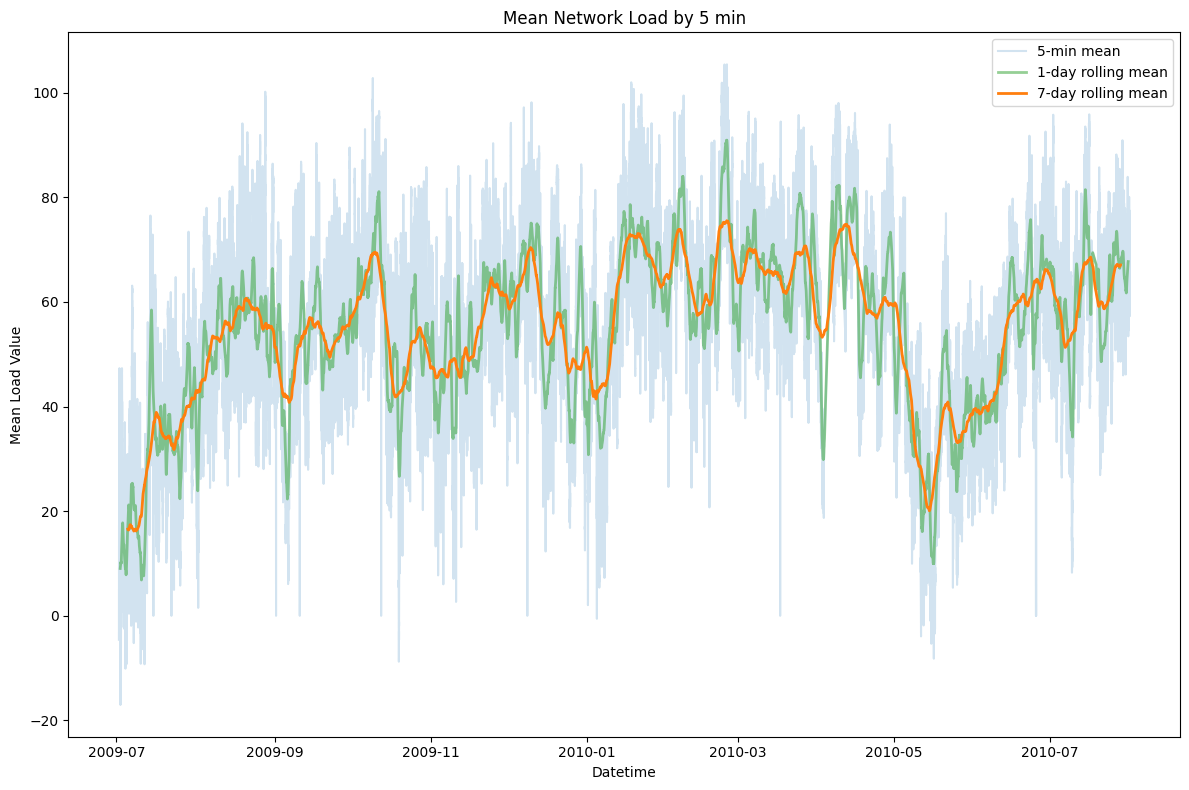

In [0]:
agg = df.set_index('DATETIME').groupby(pd.Grouper(freq='5T'))['VALUE'].mean()

rolling = agg.rolling(window=288*7, center=True).mean()
rolling_day = agg.rolling(window=288*1, center=True).mean()

plt.figure(figsize=(12, 8))
plt.plot(agg.index, agg.values, alpha=0.2, label='5‑min mean')
plt.plot(rolling_day.index, rolling_day.values, alpha=0.5, lw=2, color='C2', label='1‑day rolling mean')
plt.plot(rolling.index, rolling.values, lw=2, color='C1', label='7‑day rolling mean')
plt.title("Mean Network Load by 5 min")
plt.xlabel("Datetime")
plt.ylabel("Mean Load Value")
plt.legend()
plt.tight_layout()
plt.show()

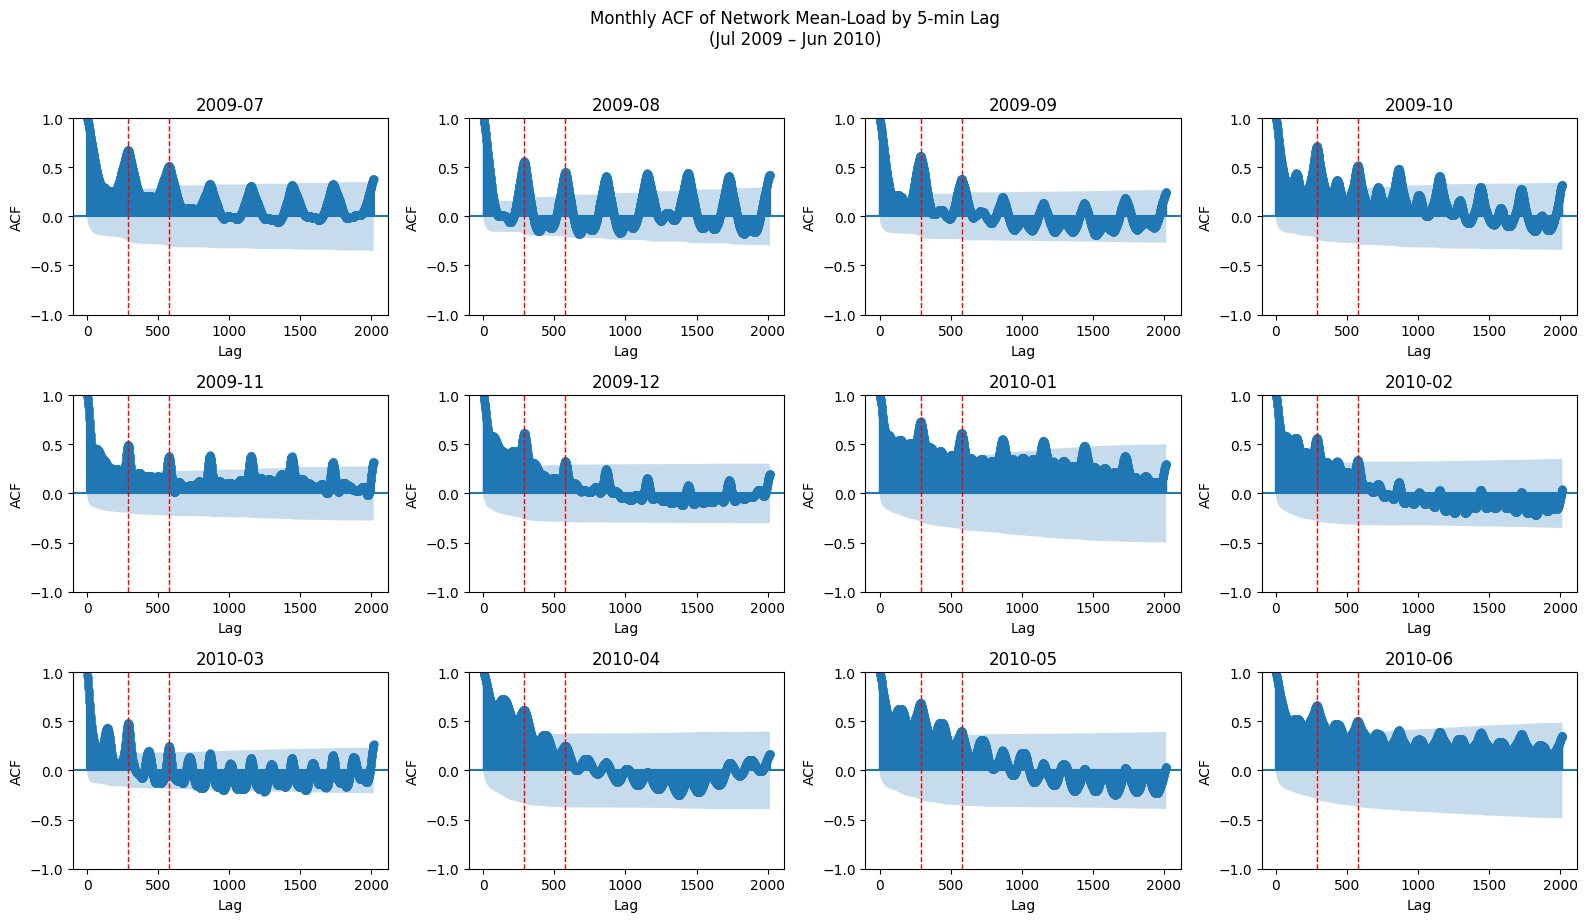

In [0]:
months = [(2009, m) for m in range(7, 13)] + [(2010, m) for m in range(1, 7)]

ncols = 4
nrows = 3
fig, axes = plt.subplots(nrows, ncols, figsize=(4*ncols, 3*nrows))
axes = axes.flatten()

for ax, (yr, mo) in zip(axes, months):
    series = agg[(agg.index.year == yr) & (agg.index.month == mo)]
    plot_acf(series, lags=288*7, ax=ax, zero=False, title=f"{yr}-{mo:02d}")
    # mark lag = 288 (1 day) and lag = 576 (2 days)
    ax.axvline(288, color='red', linestyle='--', linewidth=1)
    ax.axvline(576, color='red', linestyle='--', linewidth=1)
    ax.set_xlabel("Lag")
    ax.set_ylabel("ACF")

fig.suptitle("Monthly ACF of Network Mean‐Load by 5‑min Lag\n(Jul 2009 – Jun 2010)", y=1.02)
plt.tight_layout()
plt.show()

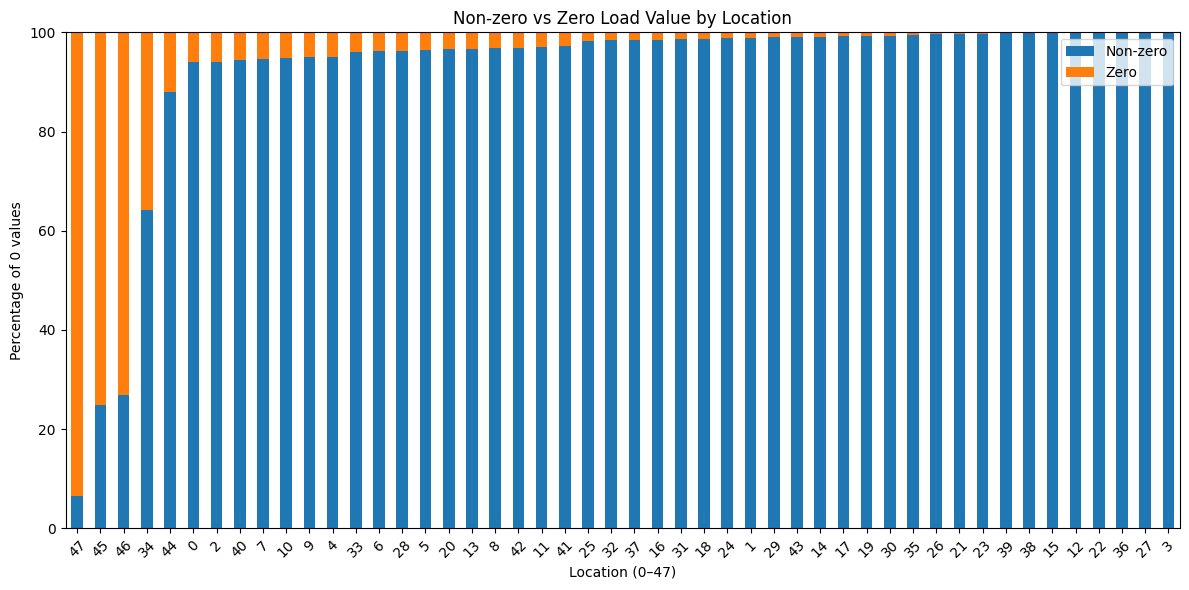

In [0]:
#Filter to the first 48 locations
first48 = df[df.LOCATION < 48]

counts = first48.groupby('LOCATION')['VALUE'].agg(
    zeros = lambda x: (x == 0).sum(),
    nonzeros = lambda x: (x != 0).sum()
)

pct = counts.div(counts.sum(axis=1), axis=0) * 100

pct = pct.sort_values('zeros', ascending=False)

ax = pct.plot(kind='bar',
              y=['nonzeros','zeros'],
              stacked=True,
              figsize=(12,6),
              color=['C0','C1'])

ax.set_ylabel('Percentage of 0 values')
ax.set_xlabel('Location (0–47)')
ax.set_title('Non‑zero vs Zero Load Value by Location')
ax.legend(['Non‑zero','Zero'], title='')
ax.set_ylim(0, 100)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

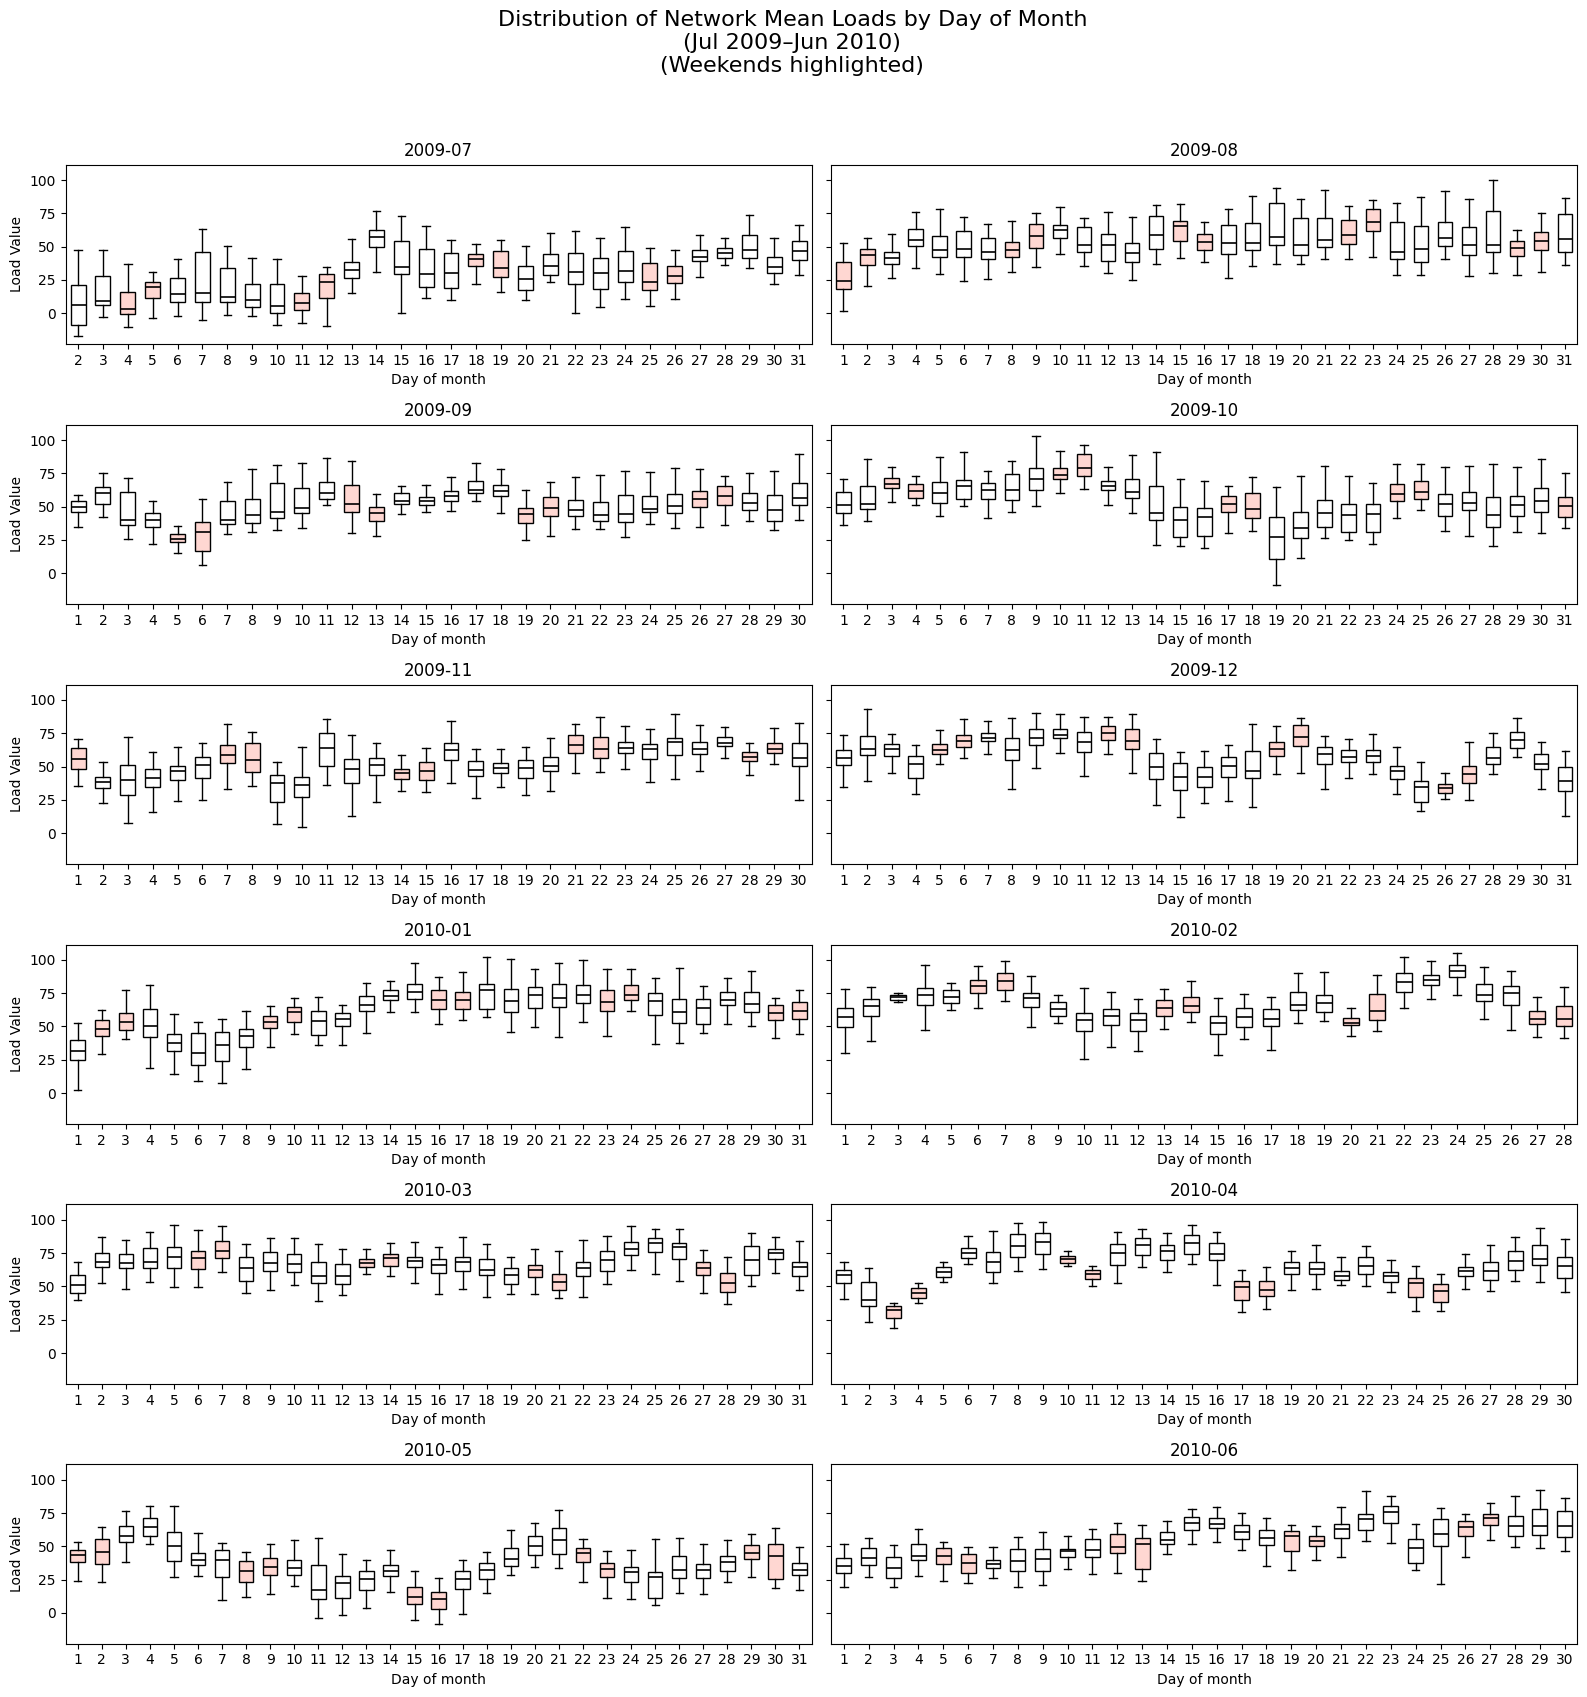

In [0]:
#5‑min aggregate
agg = df.set_index('DATETIME')['VALUE'].resample('5T').mean()

months = [(2009, m) for m in range(7,13)] + [(2010, m) for m in range(1,7)]

ncols, nrows = 2, 6
fig, axes = plt.subplots(nrows, ncols, figsize=(16, 18), sharey=True)
axes = axes.flatten()

for idx, (ax, (yr, mo)) in enumerate(zip(axes, months)):
    sel = agg[(agg.index.year == yr) & (agg.index.month == mo)].reset_index()
    sel['day'] = sel['DATETIME'].dt.day

    days = sorted(sel['day'].unique())
    box_data = [sel.loc[sel['day'] == d, 'VALUE'].values for d in days]

    bplot = ax.boxplot(
        box_data,
        positions=days,
        widths=0.6,
        showfliers=False,
        patch_artist=True
    )

    for patch, d in zip(bplot['boxes'], days):
        wd = datetime(yr, mo, d).weekday()
        if wd >= 5:
            patch.set_facecolor('#FFD7D2')
        else:
            patch.set_facecolor('white')
        patch.set_edgecolor('black')

    for median in bplot['medians']:
        median.set(color='black', linewidth=1.2)

    ax.set_title(f"{yr}-{mo:02d}")
    ax.set_xlim(min(days) - 0.5, max(days) + 0.5)
    ax.set_xticks(days)
    ax.set_xlabel("Day of month")
    if idx % ncols == 0:
        ax.set_ylabel("Load Value")

fig.suptitle(
    "Distribution of Network Mean Loads by Day of Month\n(Jul 2009–Jun 2010)",
    y=0.94,
    fontsize=16
)
plt.tight_layout(rect=[0, 0, 1, 0.92])
plt.show()

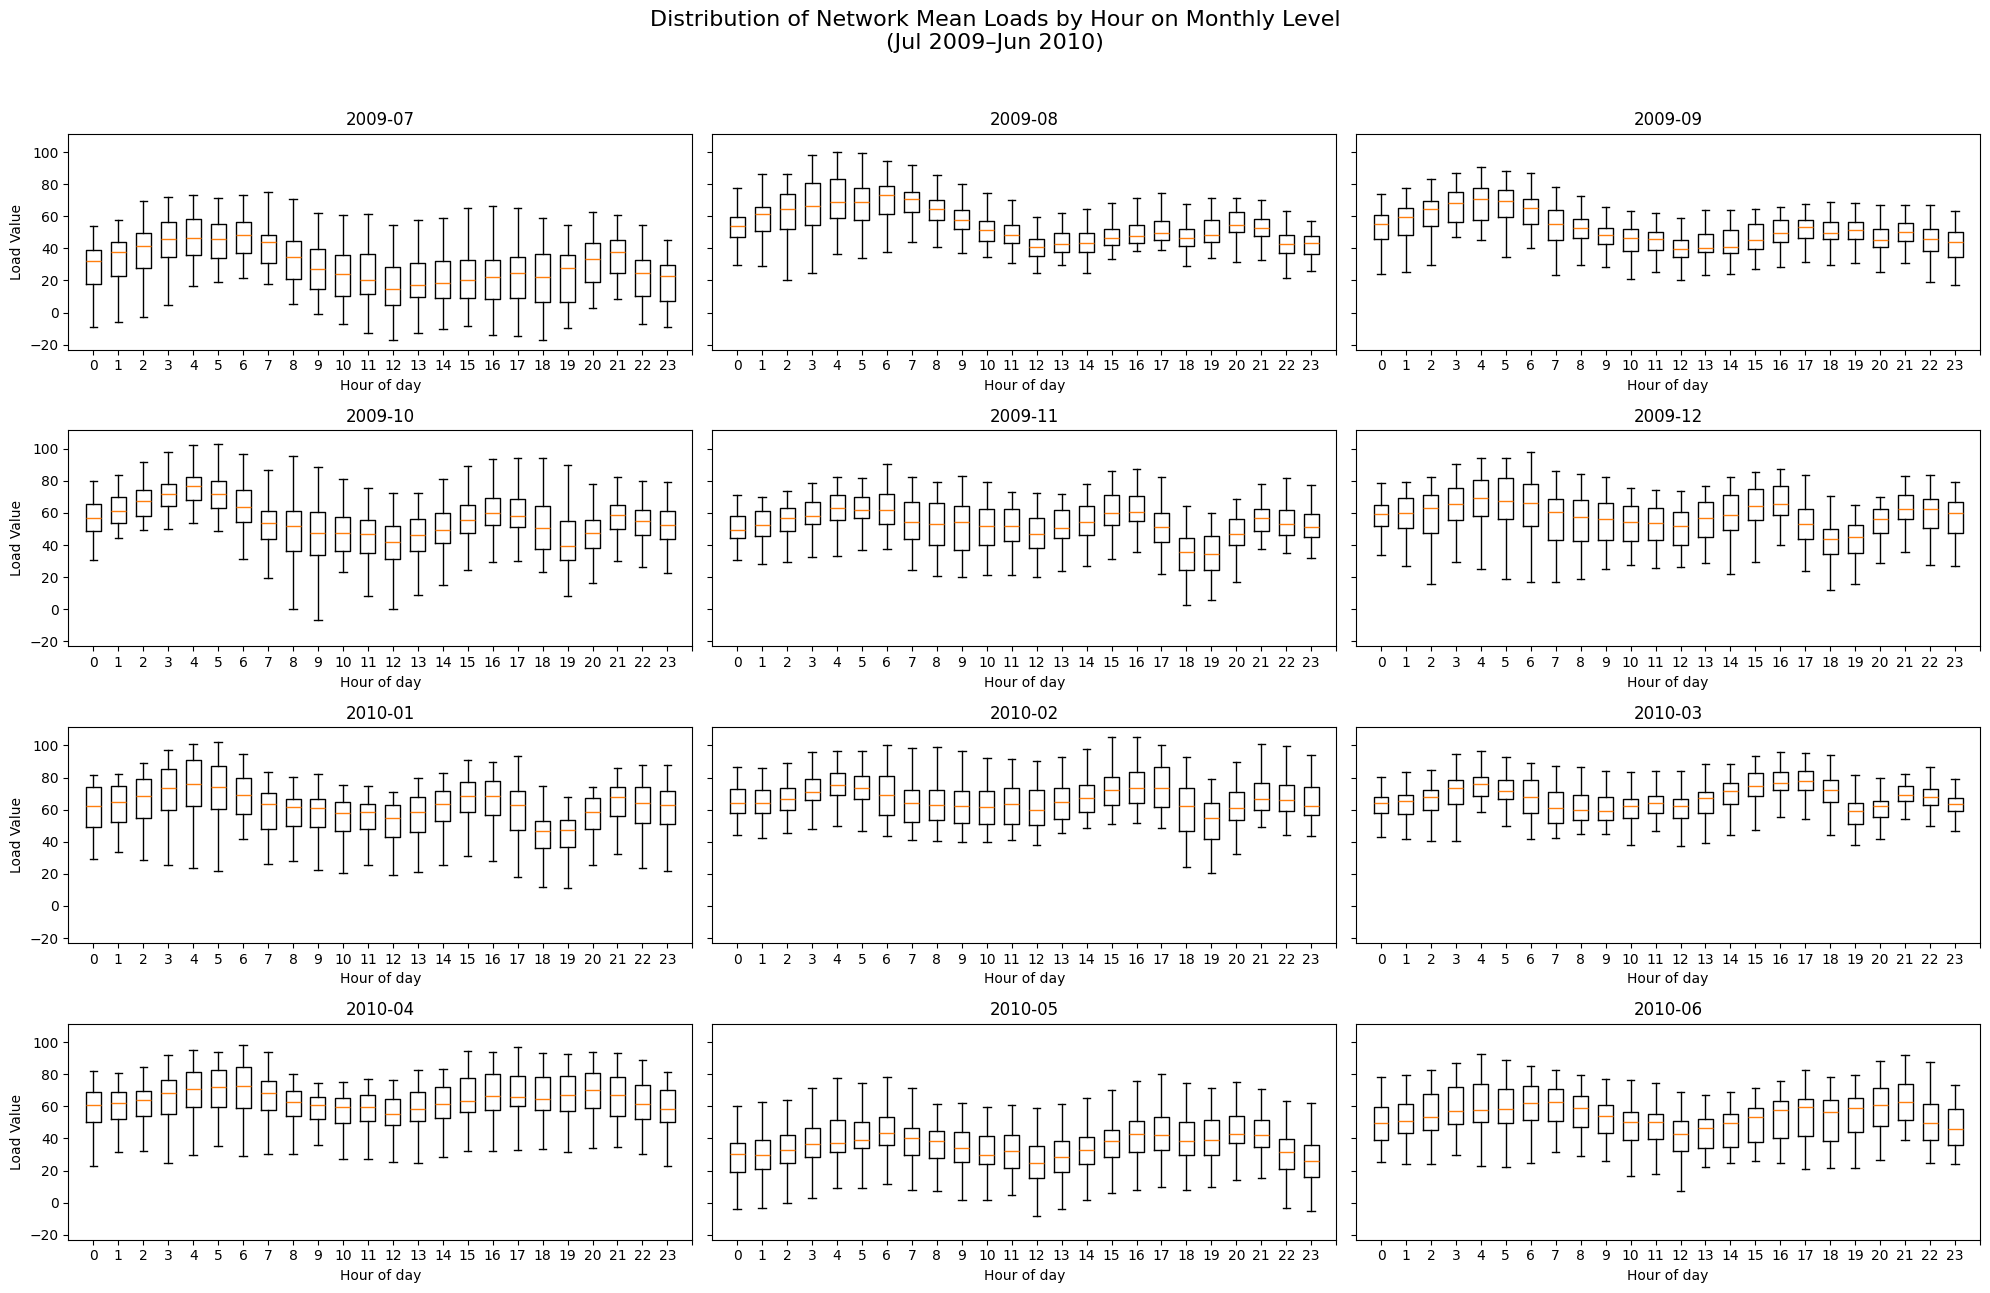

In [0]:
agg = df.set_index('DATETIME')['VALUE'].resample('5T').mean()

months = [(2009, m) for m in range(7,13)] + [(2010, m) for m in range(1,7)]

ncols = 3
nrows = 4
fig, axes = plt.subplots(nrows, ncols, figsize=(20,14), sharey=True)
axes = axes.flatten()

for idx, (ax, (yr, mo)) in enumerate(zip(axes, months)):
    sel = agg[(agg.index.year==yr) & (agg.index.month==mo)].reset_index()
    sel['hour'] = sel['DATETIME'].dt.hour

    box_data = [sel.loc[sel['hour']==h, 'VALUE'].values for h in range(24)]
    ax.boxplot(box_data, positions=range(24), widths=0.6, showfliers=False)

    ax.set_title(f"{yr}-{mo:02d}")
    ax.set_xlim(-1, 23)
    ax.set_xticks(range(25))
    ax.set_xlabel("Hour of day")

    if idx % ncols == 0:
        ax.set_ylabel("Load Value")

fig.suptitle("Distribution of Network Mean Loads by Hour on Monthly Level\n(Jul 2009–Jun 2010)", y=0.92, fontsize=16)
plt.tight_layout(rect=[0,0,1,0.90])
plt.show()

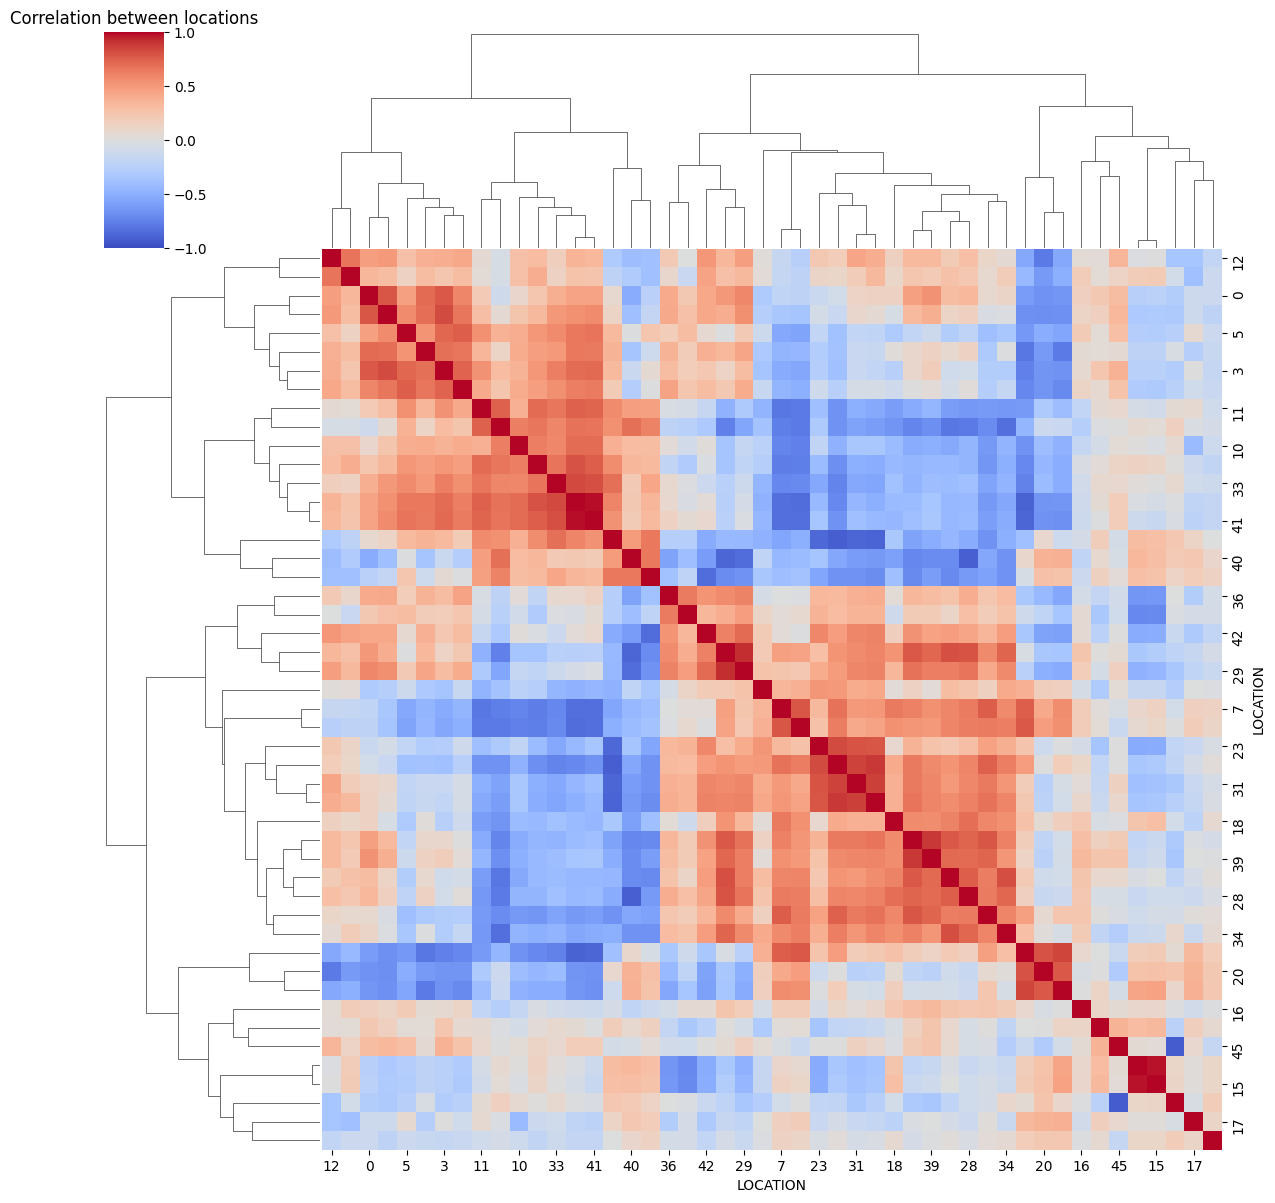

In [0]:
wide_df = df[df['LOCATION'] < 48].copy(deep=True)
wide = wide_df.pivot(index='DATETIME', columns='LOCATION', values='VALUE').fillna(method='ffill')

corr = wide.corr()

sns.clustermap(corr, figsize=(12,12), cmap='coolwarm', vmax=1, vmin=-1)
plt.title('Correlation between locations')
plt.show()